In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, classification_report,roc_auc_score,roc_curve,RocCurveDisplay
import os
from sklearn.impute import SimpleImputer
os.chdir('/home/pgcp-ai/MachineLearning/Cases/Cancer/')

In [58]:
cancer = pd.read_csv('Cancer.csv',index_col='subjid')
cancer

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
subjid,,,,,,,,,,
1,40-49,premeno,15 to 19,0 to 2,yes,three,right,left_up,no,recurrence-events
2,50-59,ge40,15 to 19,0 to 2,no,one,right,central,no,no-recurrence-events
3,50-59,ge40,35 to 39,0 to 2,no,two,left,left_low,no,recurrence-events
4,40-49,premeno,35 to 39,0 to 2,yes,three,right,left_low,yes,no-recurrence-events
5,40-49,premeno,30 to 34,3 to 5,yes,two,left,right_up,no,recurrence-events
...,...,...,...,...,...,...,...,...,...,...
282,50-59,ge40,30 to 34,6 to 8,yes,two,left,left_low,no,no-recurrence-events
283,50-59,premeno,25 to 29,3 to 5,yes,two,left,left_low,yes,no-recurrence-events
284,30-39,premeno,30 to 34,6 to 8,yes,two,right,right_up,no,no-recurrence-events


In [59]:
cancer.isna().sum()

age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    1
irradiat       0
Class          0
dtype: int64

In [60]:
imputer = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')
cancer['node-caps'] = imputer.fit_transform(cancer[['node-caps']])
cancer['breast-quad'] = imputer.fit_transform(cancer[['breast-quad']])

In [61]:
cancer.isna().sum()

age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
Class          0
dtype: int64

In [62]:
le = LabelEncoder()
cancer["Class"] = le.fit_transform(cancer["Class"])


In [63]:
X, y = cancer.drop("Class", axis = 1), cancer["Class"]

In [64]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=26)

### `ValueError: Found unknown categories [nan] in column 7 during transform` handle using handle_unknown='ignore'

In [65]:
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore').set_output(transform='pandas')

In [66]:
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

In [67]:
nb = BernoulliNB()
nb.fit(X_train_ohe,y_train) # Calculates all the apriori probabilities and 
y_pred_prob = nb.predict_proba(X_test_ohe) # Calculates the posterior probabilites

In [68]:
print(f"ROC-AUC Score is: {roc_auc_score(y_test,y_pred_prob[:,1])}")

ROC-AUC Score is: 0.6913461538461538


In [69]:
y_pred = nb.predict(X_test_ohe)
y_pred_labels  = le.inverse_transform(y_pred)

In [70]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

Accuracy Score: 0.7093023255813954


In [71]:
log_loss(y_test, y_pred_prob)

0.6138231505587957

In [72]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        60
           1       0.52      0.46      0.49        26

    accuracy                           0.71        86
   macro avg       0.65      0.64      0.64        86
weighted avg       0.70      0.71      0.70        86



#### Telecom

In [73]:
os.chdir('/home/pgcp-ai/MachineLearning/Datasets/')

In [74]:
tel = pd.read_csv('Telecom.csv')
tel

,Gender,TT_gt_100,Response
0,F,Y,N
1,M,N,N
2,M,N,N
3,F,Y,Y
4,F,N,N
...,...,...,...
145,F,Y,Y
146,M,N,Y
147,M,N,N
148,M,N,N


In [75]:
tel['Response'] = le.fit_transform(tel['Response'])
tel

,Gender,TT_gt_100,Response
0,F,Y,0
1,M,N,0
2,M,N,0
3,F,Y,1
4,F,N,0
...,...,...,...
145,F,Y,1
146,M,N,1
147,M,N,0
148,M,N,0


In [76]:
X, y = tel.drop("Response", axis = 1), tel["Response"]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y, random_state = 26)

In [78]:
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

In [79]:
nb = BernoulliNB()
nb.fit(X_train_ohe, y_train)
y_pred = nb.predict(X_test_ohe)
y_pred_proba = nb.predict_proba(X_test_ohe)

In [80]:
print(f"ROC-AUC Score is: {roc_auc_score(y_test,y_pred_proba[:,1])}")

ROC-AUC Score is: 0.9140316205533597


In [81]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91        22
           1       0.95      0.87      0.91        23

    accuracy                           0.91        45
   macro avg       0.91      0.91      0.91        45
weighted avg       0.91      0.91      0.91        45



In [82]:
fpr,tpr,thres = roc_curve(y_test,y_pred_proba[:,1])

In [88]:
import matplotlib.pyplot as plt

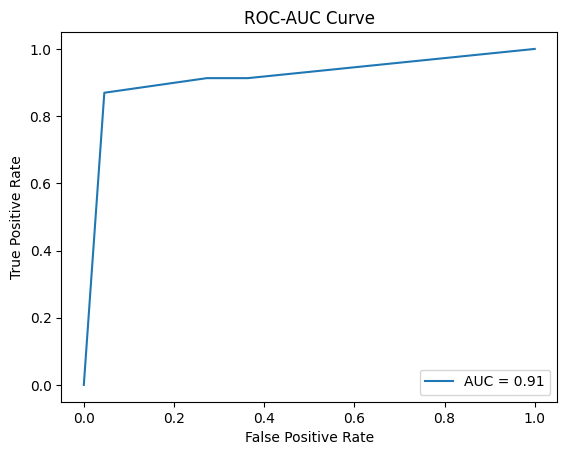

In [91]:
display = RocCurveDisplay(roc_auc=roc_auc_score(y_test,y_pred_proba[:,1]),fpr=fpr,tpr=tpr)
display.plot()
plt.title("ROC-AUC Curve")
plt.show()